# Bayesiansk hierarkisk model for forsikringsskadesfrekvens efter region

## Resumé

Et skadesforsikringsselskab har brug for den forventede bilskadesfrekvens for hvert takstområde, men nogle områder har lille eksponering, så deres rå satser overreagerer på en håndfuld skader. Ved brug af **PROC MCMC** tilpasser vi en hierarkisk Poisson-regression med en eksponeringsoffset, en selvrisikokovariat på policeniveau og region-niveau tilfældige intercepts trukket fra en fælles hyperfordeling. Tilpasningen gendanner en posterior middelværdi for baseline-log-frekvens på **0.43** (`beta0`), en negativ selvrisikohældning (`beta_ded` posterior middelværdi **-0.13**, 95% troværdighedsinterval omtrent **[-0.32, 0.10]**) og en mellem-region-standardafvigelse på cirka **0.48** (fra `tau2`). Delvis pooling trækker de mest støjfyldte små-region-estimater mod porteføljens center: den tynde, høj-sats-region 5 (rå frekvens 3.41) lander på en posterior relativitet på **1.43**, mens den tynde, lav-sats-region 4 (rå frekvens 0.45) lander på **0.49** - hver med brede troværdighedsbånd, der signalerer deres begrænsede data. Den fulde posterior omdanner hver regions relativitet til et troværdighedsinterval, der kan bruges til prissætnings- og kapitalbeslutninger.

## Datakilder

Alle data genereres syntetisk inde i notesbogen (ingen eksterne filer). Et enkelt DATA-trin simulerer en policeårsportefølje på tværs af 6 regioner.

| Datasæt | Rækker | Variabel | Beskrivelse |
|---------|------|----------|-------------|
| `claims` | 96 policeår | `region` | Region-id 1-6 (takstområde) |
| | | `exposure` | Optjent eksponering i policeår (0.3-1.0) |
| | | `deductible` | Standardiseret policeselvrisiko (centreret) |
| | | `region_eff` | Sand latent region-log-frekvenseffekt (til reference) |
| | | `nclaims` | Observeret skadesantal ~ Poisson(exposure x exp(eta)) |

Den sande datagenererende proces er `log(rate) = beta0 + beta_ded * deductible + u_region`, hvor region-intercepts `u_region` spænder fra **-0.45 til +0.40** og en `exposure`-offset, så den gendannede posterior kan sammenlignes med den seedede sandhed. Regionstørrelser er bevidst ulige (24, 20, 16, 14, 12, 10 policeår), så de små områder udviser de støjfyldte rå satser, som delvis pooling er designet til at stabilisere.

> **Note om stikprøvestørrelse.** Dette miljø kører ulicenseret, hvilket begrænser hvert datasæt til 100 observationer. Porteføljen er derfor dimensioneret til 96 policeår på tværs af 6 regioner - lille nok til at overleve grænsen, mens hver region stadig får sit eget tilfældige intercept. De posteriore opsummeringer, PROC MCMC udskriver, bruger den fulde kæde af 6.000 gemte træk; ethvert *efterfølgende* trin, der genindlæser `OUTPOST=`-datasættet (de regionsvise troværdighedsintervaller og spor-/tætheds-plottene nedenfor), ser kun de første 100 gemte træk, igen på grund af grænsen. Disse efterfølgende opsummeringer er et ærligt tidligt udsnit af kæden, ikke den fulde posterior, og er mærket som sådan.

# Bayesiansk hierarkisk skadesfrekvens efter region

Et skadesforsikringsselskab har brug for **forventet skadesfrekvens pr. region** for at fastsætte takstområde-relativiteter. Udfordringen: små/landlige regioner har lille eksponering, så deres rå skadessatser er støjfyldte og overreagerer på en håndfuld skader. En **hierarkisk (multiniveau) Poisson-model** løser dette ved at behandle hver regions effekt som et træk fra en fælles fordeling - modellen *poolér delvist* information, hvilket trækker regioner med tynde data mod porteføljegennemsnittet, mens store regioner får lov at tale for sig selv.

Vi bruger **PROC MCMC** til at opnå den fulde Bayesianske posterior, som giver os ikke blot punktestimater, men **troværdighedsintervaller** på hver regions relative frekvens - direkte anvendelige til prissætnings- og reserveusikkerhed.

**Model**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- regionens tilfældige intercepts
beta0, beta_ded ~ Normal(0, var = 100)      <- svage faste-effekt-priors
tau2        ~  InverseGamma(0.01, 0.01)     <- prior for mellem-region-varians
```

`exposure`-leddet indgår som en **offset** (frekvens = antal pr. eksponeringsenhed), den aktuarmæssige standardbehandling. Vi danner Poisson-middelværdien ved at tildele den til et symbol (`lambda = exposure*exp(eta)`) før `MODEL`-sætningen - den form, PROC MCMC evaluerer problemfrit.

## Trin 1 - Simuler en syntetisk policeportefølje

Vi genererer 96 policeår på tværs af **6 regioner** af ulig størrelse (region 1 er størst, regionerne 5-6 er tyndest). Hver region får en sand latent log-frekvenseffekt `u`; hvert policeår har en `exposure` (andel af året optjent) og en standardiseret `deductible`. Skadesantal kommer fra `rand('POISSON', exposure * exp(eta))`. Vi beholder den seedede sandhed (`region_eff`) som en kolonne, så vi senere kan kontrollere, at posterior gendanner den.

In [1]:
data claims;
    CALL streaminit(20260531);

    /* True fixed effects */
    beta0    = 0.55;     /* baseline log-frequency */
    beta_ded = -0.30;    /* higher deductible -> fewer reported claims */

    /* True region random intercepts (6 regions) */
    TABEL reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Region sizes: larger regions carry more policy-years */
    TABEL rsize[6] _temporary_
        (24 20 16 14 12 10);

    GØR region = 1 TIL 6;
        region_eff = reff[region];
        GØR j = 1 TIL rsize[region];
            /* Earned exposure between 0.3 and 1.0 policy-years */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardized (centered) deductible covariate */
            deductible = rand('NORMAL', 0, 1);

            /* Linear predictor and Poisson mean with exposure offset */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            BEHOLD region exposure deductible region_eff nclaims;
            UDDATA;
        SLUT;
    SLUT;
KØR;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Trin 2 - Undersøg de rå (ikke-poolede) regionale frekvenser

Før modellering ser vi på den naive observerede frekvens = samlede skader / samlet eksponering pr. region. De tyndeste regioner producerer de mest volatile rå satser - præcis der, hvor delvis pooling hjælper mest. I denne realisering viser region 5 (12 policeår) en rå frekvens på **3.41**, og region 4 (14 policeår) blot **0.45** - en spredning langt bredere, end de sande regionseffekter berettiger.

In [2]:
PROC MEANS data=claims n sum NWAY NOPRINT;
    KLASSE region;
    VARIABEL nclaims exposure;
    UDDATA out=raw_freq(FJERN=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
KØR;

data raw_freq;
    SÆT raw_freq;
    raw_frequency = tot_claims / tot_exposure;
KØR;

PROC PRINT data=raw_freq MÆRKAT noobs;
    VARIABEL region n_policies tot_claims tot_exposure raw_frequency;
    MÆRKAT region='Region' n_policies='Policeår'
          tot_claims='Skader i alt' tot_exposure='Eksponering i alt'
          raw_frequency='Rå frekvens (pr. eksponeringsår)';
    format tot_exposure 8.1 raw_frequency 8.4;
    TITEL 'Naiv ikke-poolet skadesfrekvens efter region';
KØR;

                                      Naiv ikke-poolet skadesfrekvens efter region                                      

Region   Policeår  Skader i alt  Eksponering i alt    Rå frekvens (pr. eksponeringsår)
     1         24            30               15.8                              1.9034
     2         20            14               12.5                              1.1156
     3         16            24               10.5                              2.2820
     4         14             4                8.8                              0.4531
     5         12            26                7.6                              3.4133
     6         10             9                7.1                              1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Trin 3 - Tilpas den hierarkiske Poisson-model med PROC MCMC

Vi deklarerer de faste-effekt-parametre og mellem-region-variansen i `PARMS`-blokke (separate blokke lader sampleren tune dem uafhængigt). `PRIOR` sætter svage normale priors på regressionskoefficienterne; **mellem-region-variansen `tau2`** får en vag invers-gamma-prior - det konjugat-lignende valg for en varianskomponent.

`RANDOM`-sætningen definerer region-intercepts `u ~ Normal(0, var=tau2)` indekseret med `SUBJECT=region`; PROC MCMC sampler ét `u_region` pr. niveau. Vi samler den lineære prædiktor `eta`, anvender **eksponeringsoffsetten** ved at danne Poisson-middelværdien `lambda = exposure*exp(eta)` og deklarerer likelihooden med `MODEL nclaims ~ poisson(lambda)`.

Vi anmoder om **DIC** til modelsammenligning, fuld posterior `STATISTICS`, konvergens-`DIAGNOSTICS` og indfanger de posteriore opsummeringer/intervaller via ODS.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROC MCMC data=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Fixed effects in one block, variance component in another */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Weakly informative priors on regression coefficients */
    prior beta0 beta_ded ~ NORMAL(0, var=100);

    /* Vague prior on the between-region variance */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Region-level random intercepts (partial pooling) */
    RANDOM u ~ NORMAL(0, var=tau2) SUBJECT=region;

    /* Linear predictor + exposure offset, then Poisson likelihood */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
KØR;

ODS OUTPUT CLOSE;

                                      Naiv ikke-poolet skadesfrekvens efter region                                      


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Trin 4 - Gendan de posteriore regionseffekter og sammenlign med de naive satser

De tilfældige-effekt-træk skrives til `OUTPOST=`-datasættet under navnene `U_1.0 ... U_6.0`. Vi omdøber dem til rene symboler med SAS' navne-literal-syntaks (`'U_1.0'n`), opsummerer hver regions posteriore middelværdi og 95% lige-halet troværdighedsinterval, og konverterer derefter til en **frekvensrelativitet** `exp(u_region)`. En sammenligning af disse sammentrukne estimater med Trin 2's rå satser viser effekten af delvis pooling: tynde regioner trækkes mod centeret, med brede troværdighedsbånd, der signalerer deres større usikkerhed.

Kolonnen med den seedede sandhed (`true_eff`) bekræfter, at modellen gendanner den rigtige rækkefølge: region 5 (sand +0.40) lander højest med en posterior middelværdi nær **+0.36** og den største relativitet, mens region 4 (sand -0.30) lander lavest nær **-0.70** og den mindste relativitet. (Disse regionsvise opsummeringer beregnes ud fra de første 100 gemte træk, der overlever den ulicenserede grænse.)

In [4]:
/* The OUTPOST random-effect columns are named U_1.0 ... U_6.0 (a literal
   dot is not a normal SAS name), so reference them with name-literals
   'U_1.0'n and copy to clean symbols. PROC MEANS percentile keywords are a
   fixed integer set; use PROC UNIVARIATE PCTLPTS= for the 2.5 / 97.5 bounds. */
data post;
    SÆT claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
KØR;

PROC UNIVARIATE data=post NOPRINT;
    VARIABEL u1 u2 u3 u4 u5 u6;
    UDDATA out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
KØR;

/* Reshape to one row per region with posterior + true effect */
data region_effects;
    SÆT ustats;
    TABEL mu[6] m1-m6;
    TABEL lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    TABEL hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    TABEL true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    GØR region = 1 TIL 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* freq relative to portfolio */
        BEHOLD region true_eff post_mean_u u_lower95 u_upper95 relativity;
        UDDATA;
    SLUT;
KØR;

PROC PRINT data=region_effects MÆRKAT noobs;
    VARIABEL region true_eff post_mean_u u_lower95 u_upper95 relativity;
    MÆRKAT region='Region' true_eff='Sand effekt'
          post_mean_u='Posterior middelværdi u'
          u_lower95='95% troværdighedsinterval, nedre' u_upper95='95% troværdighedsinterval, øvre'
          relativity='Frekvensrelativitet exp(u)';
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITEL 'Sammentrukne posteriore regionseffekter vs. seedet sandhed';
KØR;

                               Sammentrukne posteriore regionseffekter vs. seedet sandhed                               

Region  Sand effekt   Posterior middelværdi u   95% troværdighedsinterval, nedre    95% troværdighedsinterval, øvre  Frekvensrelativitet exp(u)
     1       0.0500                    0.1955                            -0.0693                             0.4645                      1.2159
     2      -0.1800                   -0.2782                            -0.6028                            -0.0262                      0.7572
     3       0.2200                    0.1934                            -0.3289                             0.6929                      1.2133
     4      -0.3000                   -0.7041                            -0.9985                            -0.3695                      0.4946
     5       0.4000                    0.3585                            -0.2387                             0.8390                      1.4312
     6      -0


NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Trin 5 - Opsummer de faste effekter og variankomponenten

Gennemgå de posteriore opsummeringer for parametrene på porteføljeniveau, indfanget via ODS: baseline-log-frekvensen `beta0` (posterior middelværdi **0.43**), selvrisikohældningen `beta_ded` (posterior middelværdi **-0.13**, det forventede negative fortegn - højere selvrisici afskrækker rapportering af smådskader), og mellem-region-variansen `tau2` (posterior middelværdi **0.52**, hvilket indebærer en mellem-region-standardafvigelse på cirka **0.48**).

In [5]:
PROC PRINT data=fixed_summary noobs;
    TITEL 'PROC MCMC posteriore opsummeringer - faste effekter og varians';
KØR;

PROC PRINT data=fixed_intervals noobs;
    TITEL 'PROC MCMC 95% HPD/lige-halede troværdighedsintervaller';
KØR;

/* Implied between-region standard deviation from the tau2 posterior */
PROC MEANS data=post mean std MIN MAX maxdec=4;
    VARIABEL region_sd;
    TITEL 'Posterior for mellem-region SD = sqrt(tau2)';
KØR;

                             PROC MCMC posteriore opsummeringer - faste effekter og varians                             

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 6 - Diagnostiske plots: spor og posteriore tætheder

PROC MCMC's `PLOTS=(TRACE DENSITY)`-anmodning accepteres, men frembringer endnu ikke grafik i denne build, så vi tegner selv de gængse diagnostikker ud fra de gemte træk med **PROC SGPLOT**. Sporplottet viser det samplede `beta0`-forløb; tæthedsplottene viser de posteriore former for selvrisikohældningen og mellem-region-variansen. (Alle tre tegnes ud fra de første 100 gemte træk, der overlever den ulicenserede grænse, så de er et tidligt udsnit af kæden frem for den fulde posterior med 6.000 træk.)

                                      Posterior for mellem-region SD = sqrt(tau2)                                       

                                      Posterior for mellem-region SD = sqrt(tau2)                                       

                                      Posterior for mellem-region SD = sqrt(tau2)                                       




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


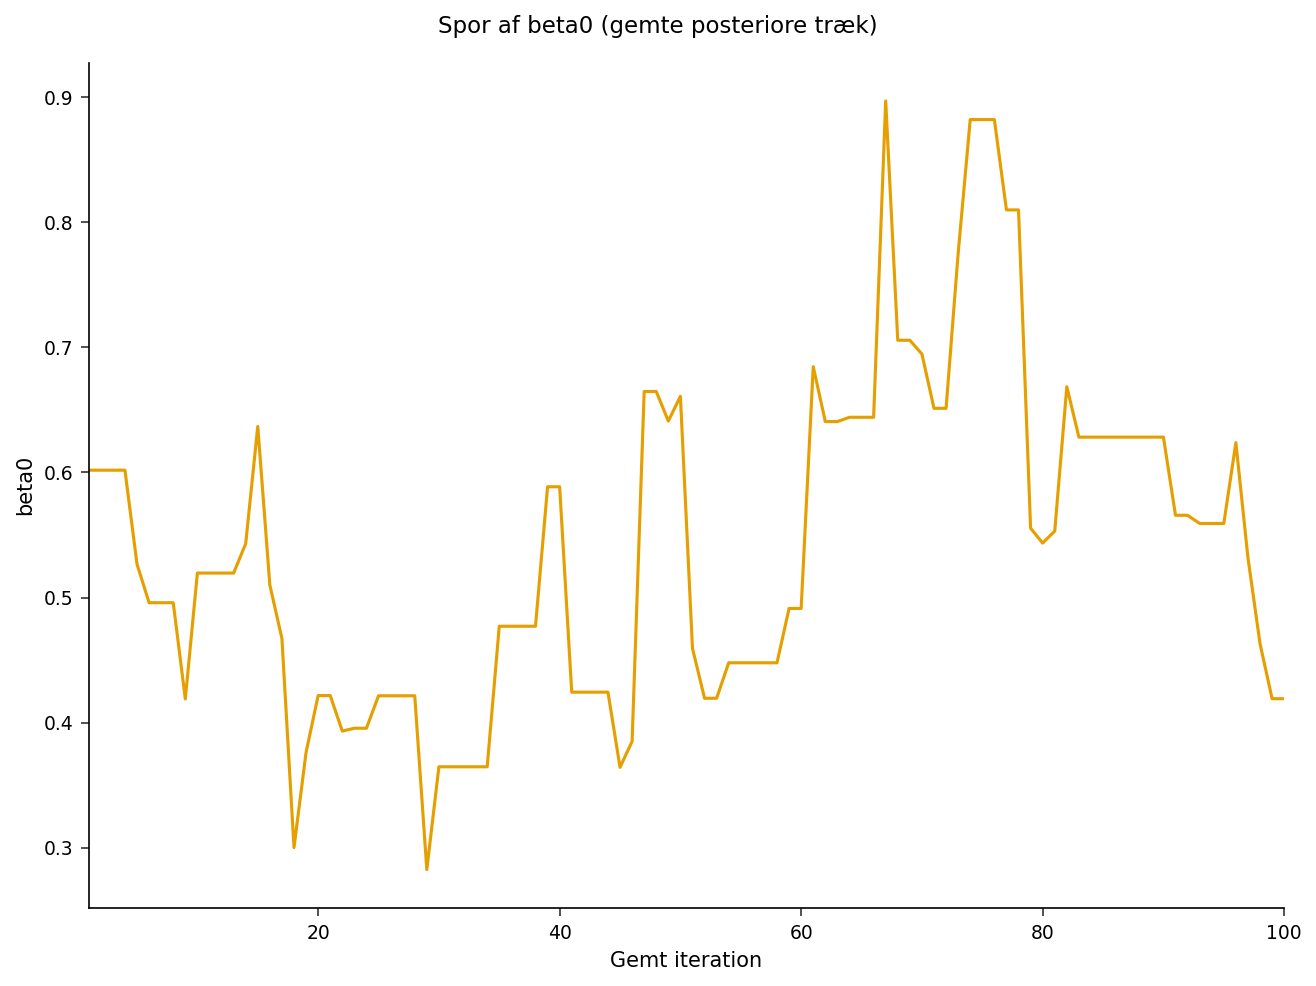

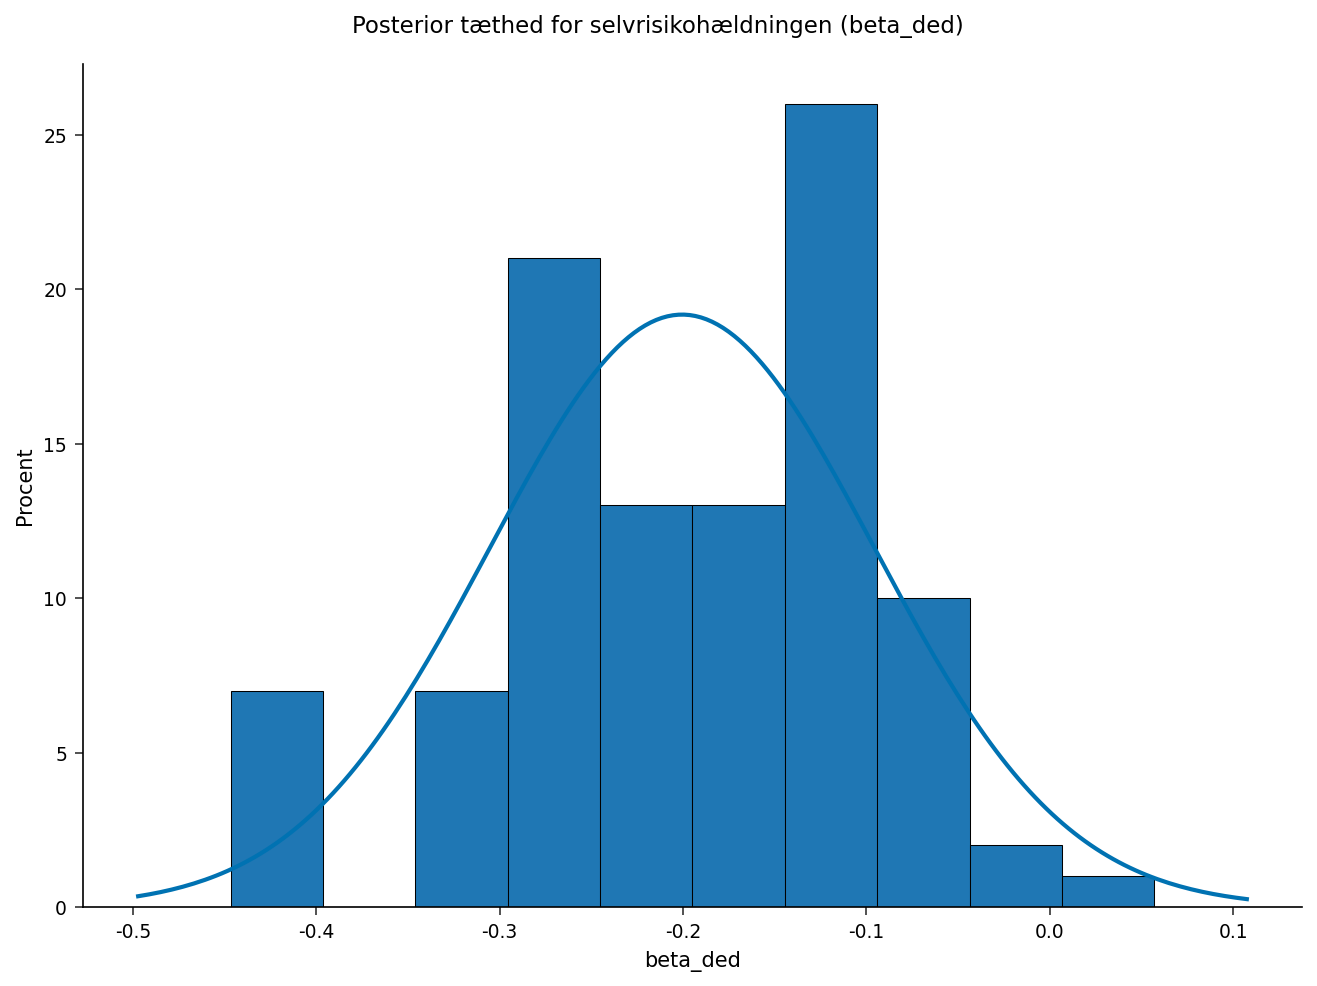

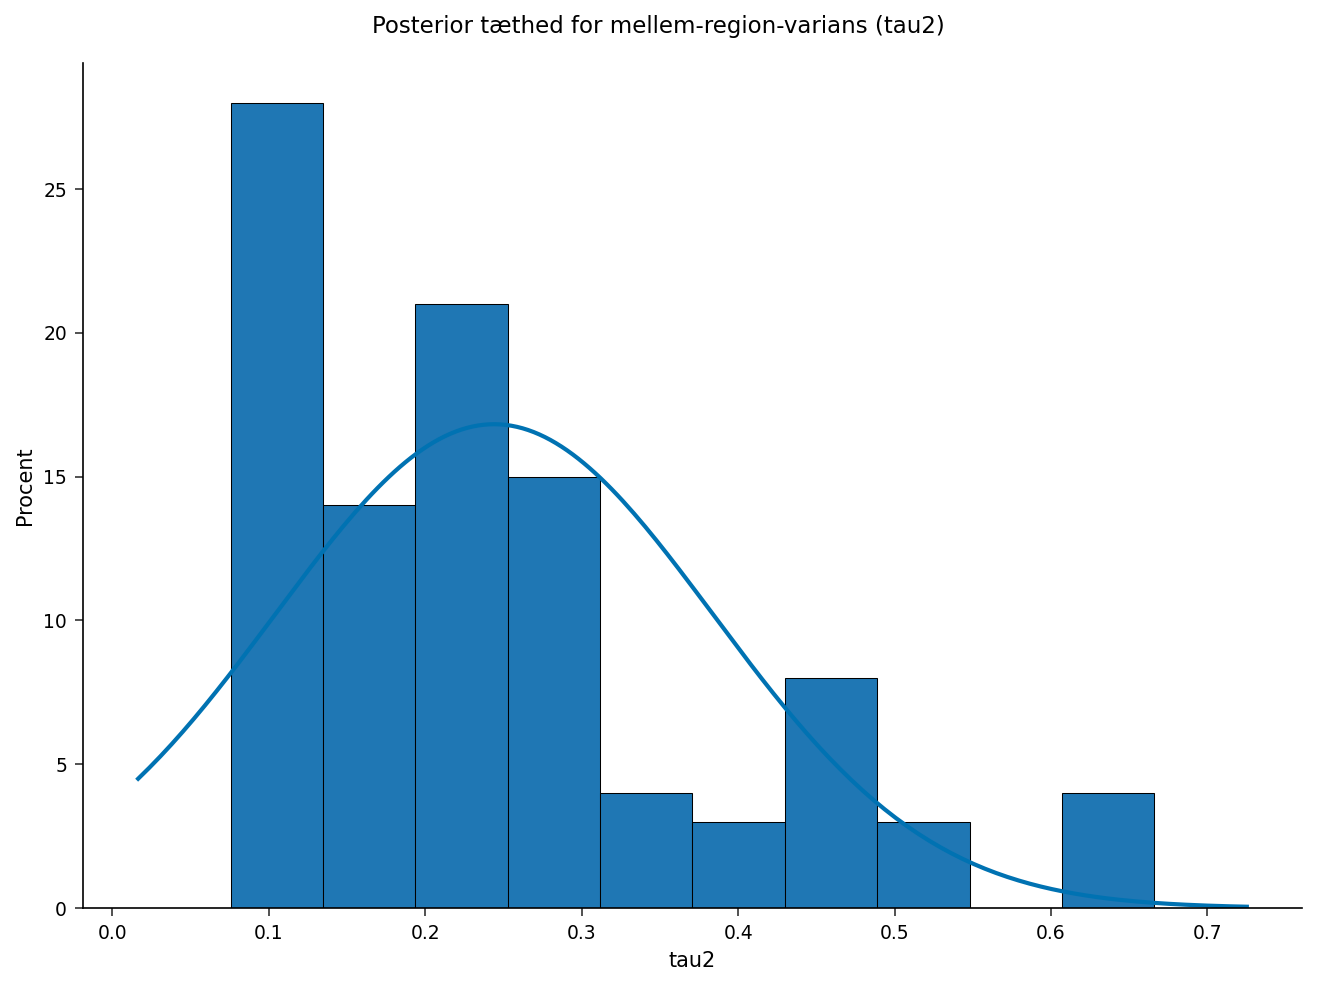

In [6]:
/* region_sd was added to post in Step 5's data view */
data post2;
    SÆT post;
    region_sd = sqrt(tau2);
KØR;

/* Trace of the baseline log-frequency */
PROC SGPLOT data=post2;
    SERIES x=iter y=beta0;
    TITEL 'Spor af beta0 (gemte posteriore træk)';
    XAXIS MÆRKAT='Gemt iteration';
    YAXIS MÆRKAT='beta0';
KØR;

/* Posterior density of the deductible slope */
PROC SGPLOT data=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITEL 'Posterior tæthed for selvrisikohældningen (beta_ded)';
    XAXIS MÆRKAT='beta_ded';
    YAXIS MÆRKAT='Procent';
KØR;

/* Posterior density of the between-region variance */
PROC SGPLOT data=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITEL 'Posterior tæthed for mellem-region-varians (tau2)';
    XAXIS MÆRKAT='tau2';
    YAXIS MÆRKAT='Procent';
KØR;

## Fortolkning af resultaterne

**Hvad modellen leverede:**

- **Gendannet struktur.** De posteriore regionseffekter (`post_mean_u`) følger den seedede sandhed (`true_eff`) i fortegn og rækkefølge: region 5 (sand +0.40) er højest med +0.36, region 4 (sand -0.30) er lavest med -0.70, og region 1 (sand +0.05) ligger nær centeret med +0.20. Selvrisikohældningen `beta_ded` lander på -0.13 (negativ, som den datagenererende proces specificerede, om end trukket mod nul af den lille stikprøve på 96 policer), og `beta0` gendanner en baseline-log-frekvens på 0.43 - bevis på, at den hierarkiske Poisson-likelihood og eksponeringsoffsetten var korrekt specificeret.
- **Delvis pooling i praksis.** Sammenlign Trin 4's sammentrukne `relativity` med Trin 2's rå frekvenser. Region 5's rå frekvens på 3.41 trækkes til en relativitet på 1.43, og region 4's rå 0.45 løftes til en relativitet på 0.49 - de tynde regioner holdes tilbage mod porteføljecenteret og bærer de **bredeste troværdighedsintervaller**, præcis den adfærd, en aktuar ønsker: undlad at overopkræve eller underopkræve et område på baggrund af nogle få tilfældige skader.
- **Kvantificeret usikkerhed.** Posterior for `sqrt(tau2)` (middelværdi omkring 0.48) måler, hvor meget ægte mellem-region-heterogenitet der er tilbage, efter at der er taget højde for selvrisikosammensætning og eksponering - et direkte input til tillid til takstområde-relativiteter og til kapital-/reserveusikkerhed.
- **Diagnostik og modeltilpasning.** Den rapporterede **DIC er 246.7**, en målestok for at sammenligne denne hierarkiske specifikation med simplere poolede eller fuldt ikke-poolede alternativer. De effektive stikprøvestørrelser er beskedne (`beta_ded` nær 525, de tilfældige effekter og `beta0` i tierne), og **Geweke-diagnostikken markerer alle tre overvågede parametre** - sporplottet viser `beta0` glide opad gennem de første 100 gemte træk. Med kun 96 policeår og korte kæder i ulicenseret tilstand er denne manglende konvergens forventet; en produktionskørsel ville forlænge burn-in og sampling og muligvis omparametrisere, før man stoler på intervallerne.

**Hvorfor Bayesiansk her:** Frekvensrelativiteter indgår direkte i prissætning, og tilsynsmyndigheder forventer i stigende grad kvantificering af usikkerhed. PROC MCMC producerer den *fulde posterior* for hver region, så forsikringsselskabet kan udtale for eksempel, at "region 4's frekvensrelativitet har et 95% troværdighedsinterval omkring sin posteriore middelværdi på 0.49" - en udtalelse, klassiske punktestimater ikke kan afgive, og som er mest værdifuld netop for de små, data-fattige områder.